<a href="https://colab.research.google.com/github/paulsubarna/CONFEDMADE/blob/main/GReplay_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TUTORIAL 4: SEQUENTIAL TRAINING WITH REPLAY BUFFERS

In this notebook, we will explore different replay buffer strategies.
- Gnerative Replay buffer using VAEs- "Store generated samples"
- Experience Replay- "Store real samples from the dataset"

#### DATA Preparation and Loading

In [1]:
import torch
from torchvision import datasets
from torchvision import transforms
from tqdm import tqdm
from torchvision.models import resnet18
import random
import matplotlib.pyplot as plt

import torchvision.datasets as datasets
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
import torchvision
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
mean = torch.tensor([0.4589, 0.4384, 0.4011])
std = torch.tensor([0.2793, 0.2724, 0.2835])

# Apply transforms
#transforms = transforms.Compose(
#    [transforms.ToTensor()
#    ])

mnist_trainset = datasets.MNIST(root='./Mnist', train=True, download=True, transform= transforms.ToTensor())
mnist_testset = datasets.MNIST(root='./Mnist', train=False, download=True, transform= transforms.ToTensor())

len(mnist_trainset), len(mnist_testset) # 60000, 10000
config = {'size': 28, 'channels': 1, 'classes': 10}

### Spliting dataset into N contexts

- Let us first divide our dataset into five sequential tasks and we will do it based on the labels
- Split with labels such that,  context 1: [0,1], context 2: [2,3],  context 1: [4,5], context 2: [6,7],  context 1: [8,9]

In [2]:
train_data_cl = []
test_data_cl = []
labels = [[0,1], [2,3], [4,5], [6,7], [8,9]]
labels_ = [[0,1], [0,1,2,3], [0,1,2,3,4,5], [0,1,2,3,4,5,6,7], [0,1,2,3,4,5,6,7,8,9]]
for j in range(5):
    train_data_cl.append([])
    test_data_cl.append([])
    for i in range(len(mnist_trainset)):
        if mnist_trainset[i][1] in labels[j]:
            train_data_cl[j].append((mnist_trainset[i][0], mnist_trainset[i][1]))
    for i in range(len(mnist_testset)):
        if mnist_testset[i][1] in labels_[j]:
            test_data_cl[j].append((mnist_testset[i][0], mnist_testset[i][1]))


#train_data_cl[0][0]

#### Sequential training

Let us now use this set of tasks to train a neural network sequentially, where we define a simple classifier or convolutational networks and train it on all the sequence of tasks  

"" TO-DO ""
- Define a simple MLP network or a Convolutional Network
- Define your training loop
- Train it on all the contexts

In [4]:
class Classifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(Classifier, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.fc1 = nn.Linear(64 * 7 * 7, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.out = nn.Linear(hidden_dim, output_dim)



    def forward(self, x):
        #x = nn.Flatten()(x)
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        #print(x.shape)
        x = x.view(x.size(0), -1)  # Flatten the input
        #print(x.shape)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.out(x)

        return x

def train_classifier(model, train_data, test_data, num_epochs=10, batch_size=32, learning_rate=0.001):
    # Define loss function and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=learning_rate)

    # Create data loaders
    train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
    test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=False)

    # Training loop
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in tqdm(train_loader):
            #inputs = inputs.view(inputs.size(0), -1)  # Flatten the input
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")

    # Evaluation loop
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            #inputs = inputs.view(inputs.size(0), -1)  # Flatten the input
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f"Accuracy of the model on the test data: {100 * correct / total:.2f}%")
model = Classifier(input_dim=28*28, hidden_dim=128, output_dim=3)
import os
if not os.path.exists('./model_replay'):
    os.makedirs('./model_replay')
model = Classifier(input_dim=28*28, hidden_dim=256, output_dim=10)
for i in range(5):

    train_classifier(model, train_data_cl[i], test_data_cl[i], num_epochs=5, batch_size=32, learning_rate=0.1)
    #torch.save(model.state_dict(), f'./model_replay/replay_{i}.pth')


  0%|          | 0/396 [00:00<?, ?it/s]

100%|██████████| 396/396 [00:02<00:00, 187.15it/s]


Epoch [1/5], Loss: 0.0940


100%|██████████| 396/396 [00:03<00:00, 109.62it/s]


Epoch [2/5], Loss: 0.0039


...

Epoch [3/5], Loss: 0.0234


100%|██████████| 369/369 [00:03<00:00, 112.12it/s]


Epoch [4/5], Loss: 0.0164


100%|██████████| 369/369 [00:03<00:00, 113.29it/s]


Epoch [5/5], Loss: 0.0135
Accuracy of the model on the test data: 19.75%


We could clearly observe the phenomenon of catastrophic forgetting here.
We should also see the same phenomenon if we have to evaluate on individial contexts where the model performs the best on the last task and bad performance on the earlier tasks

In [6]:
def evaluate_classifier(model, test_data, batch_size=32):
    # Create data loader
    test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=False)

    # Evaluation loop
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            #inputs = inputs.view(inputs.size(0), -1)  # Flatten the input
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f"Accuracy of the model on the test data: {100 * correct / total:.2f}%")

for i in range(5):
    evaluate_classifier(model, test_data_cl[i], batch_size=32)

Accuracy of the model on the test data: 0.00%
Accuracy of the model on the test data: 0.00%
Accuracy of the model on the test data: 0.00%
Accuracy of the model on the test data: 0.00%
Accuracy of the model on the test data: 19.75%


#### Accomodate Replay buffers

We have two options
- Store generative samples using VAEs
- Store real samples as experience replay

But, first, we need to define our VAE model, train it on all the contexts and obderve its efficacy to generate new data

1. Generative Replay Buffers

- We will use VAE to generate new samples, that you will store in the memory buffers
- Define your VAE model
- we will generate samples based on class instances [0], [1], etc
- So, we will train our VAE model on samples from individual class instances. That means it is necessary to split the dataset based on the samples.

##### Split the dataset per labels

In [7]:
train_data = []
test_data = []
#labels = [[0,1,2], [3,4,5], [6,7,8]]
labels = [[0], [1], [2], [3], [4], [5], [6], [7], [8], [9]]

#labels = [[0], [1], [2]]
for j in range(10):
    train_data.append([])
    test_data.append([])
    for i in range(len(mnist_trainset)):
        if mnist_trainset[i][1] in labels[j]:
            train_data[j].append((mnist_trainset[i][0], mnist_trainset[i][1]))
    for i in range(len(mnist_testset)):
        if mnist_testset[i][1] in labels[j]:
            test_data[j].append((mnist_testset[i][0], mnist_testset[i][1]))


train_data[0][0]

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 

##### Variational Autoencoder

In [8]:
class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(Encoder, self).__init__()

        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc_m = nn.Linear(hidden_dim, output_dim)
        self.fc_v = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        #x = nn.Flatten()(x)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        mu = self.fc_m(x)
        logvar = self.fc_v(x)
        return mu, logvar

class Decoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(Decoder, self).__init__()

        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, output_dim)

    def forward(self, z):
        z = F.relu(self.fc1(z))
        z = F.relu(self.fc2(z))
        z = torch.sigmoid(self.fc3(z))
        return z

class VAE(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(VAE, self).__init__()
        self.encoder = Encoder(input_dim, hidden_dim, output_dim)
        self.decoder = Decoder(output_dim, hidden_dim, input_dim)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decoder(z)
        return x_recon, mu, logvar
    def loss_function(self, x, x_recon, mu, logvar):
        BCE = F.binary_cross_entropy(x_recon, x.view(-1, 784), reduction='sum')
        KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        return BCE + 5 * KLD
    def sample(self, z):
        with torch.no_grad():
            z = torch.tensor(z).float()
            z = self.decoder(z)
            return z.view(-1, 1, 28, 28)
    def generate(self, num_samples, output_dim):
        with torch.no_grad():
            z = torch.randn(num_samples, output_dim)
            samples = self.decoder(z)
            return samples.view(-1, 1, 28, 28)

##### Train your VAE Model

100%|██████████| 93/93 [00:00<00:00, 170.87it/s]


Epoch 1, Loss: 228.7794986836274


100%|██████████| 93/93 [00:00<00:00, 184.41it/s]


Epoch 2, Loss: 197.95447434788113


100%|██████████| 93/93 [00:00<00:00, 164.52it/s]


...

Epoch 4, Loss: 173.15304496902962


100%|██████████| 93/93 [00:00<00:00, 158.88it/s]


Epoch 5, Loss: 168.51443277926094


100%|██████████| 16/16 [00:00<00:00, 585.62it/s]


Test Loss: 167.1442494917889


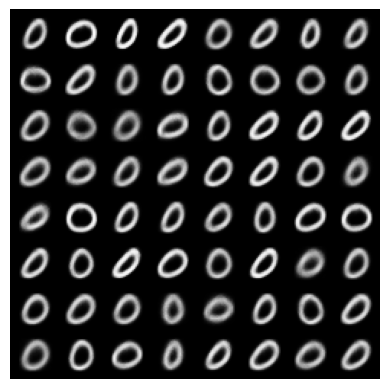

100%|██████████| 106/106 [00:00<00:00, 162.24it/s]


Epoch 1, Loss: 126.91079071868742


100%|██████████| 106/106 [00:00<00:00, 160.66it/s]


Epoch 2, Loss: 88.91732562666864


100%|██████████| 106/106 [00:00<00:00, 158.95it/s]


...

Epoch 4, Loss: 74.91280210863339


100%|██████████| 106/106 [00:00<00:00, 161.76it/s]


Epoch 5, Loss: 73.64978479992492


100%|██████████| 18/18 [00:00<00:00, 630.29it/s]

Test Loss: 72.4400661653359


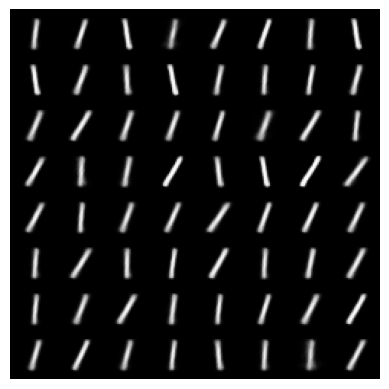

100%|██████████| 94/94 [00:00<00:00, 151.92it/s]


Epoch 1, Loss: 229.74272634679738


100%|██████████| 94/94 [00:00<00:00, 156.35it/s]


Epoch 2, Loss: 204.36782159770084


100%|██████████| 94/94 [00:00<00:00, 152.37it/s]


...

Epoch 4, Loss: 194.26342074780626


100%|██████████| 94/94 [00:00<00:00, 153.79it/s]


Epoch 5, Loss: 191.9299368651852


100%|██████████| 17/17 [00:00<00:00, 576.44it/s]

Test Loss: 188.62584964249484


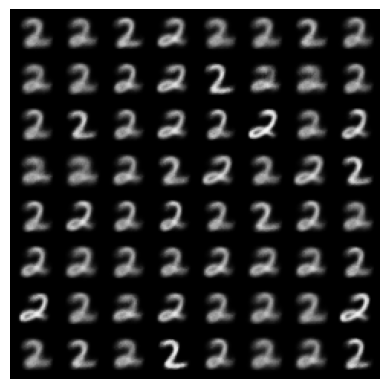

100%|██████████| 96/96 [00:00<00:00, 173.09it/s]


Epoch 1, Loss: 214.02598857241887


100%|██████████| 96/96 [00:00<00:00, 172.36it/s]


Epoch 2, Loss: 187.50508988006646


100%|██████████| 96/96 [00:00<00:00, 171.45it/s]


...

Epoch 4, Loss: 176.23025467399282


100%|██████████| 96/96 [00:00<00:00, 181.92it/s]


Epoch 5, Loss: 172.0916726344601


100%|██████████| 16/16 [00:00<00:00, 536.54it/s]

Test Loss: 168.9484645730198


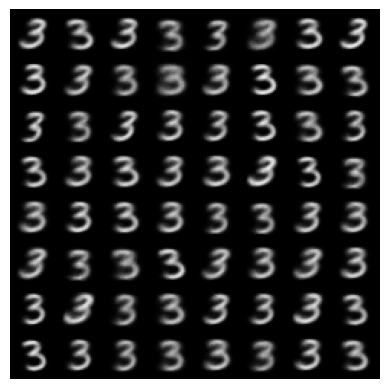

100%|██████████| 92/92 [00:00<00:00, 164.41it/s]


Epoch 1, Loss: 201.30992009973576


100%|██████████| 92/92 [00:00<00:00, 165.34it/s]


Epoch 2, Loss: 172.80074213400803


100%|██████████| 92/92 [00:00<00:00, 166.47it/s]


...

Epoch 4, Loss: 161.77281523811945


100%|██████████| 92/92 [00:00<00:00, 191.73it/s]


Epoch 5, Loss: 156.94158966889816


100%|██████████| 16/16 [00:00<00:00, 514.43it/s]

Test Loss: 152.61946656019285


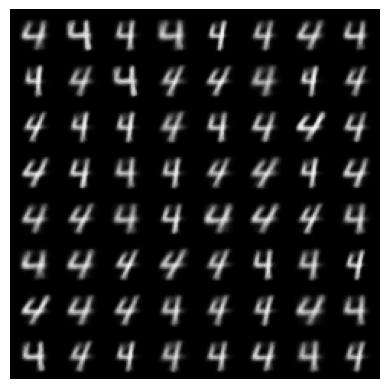

100%|██████████| 85/85 [00:00<00:00, 162.32it/s]


Epoch 1, Loss: 224.75772783215734


100%|██████████| 85/85 [00:00<00:00, 166.59it/s]


Epoch 2, Loss: 190.57552173405506


100%|██████████| 85/85 [00:00<00:00, 165.40it/s]


...

Epoch 4, Loss: 175.23512304939703


100%|██████████| 85/85 [00:00<00:00, 168.49it/s]


Epoch 5, Loss: 172.15815088313965


100%|██████████| 14/14 [00:00<00:00, 559.92it/s]

Test Loss: 171.16938980170963


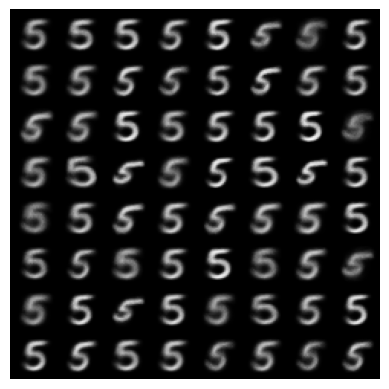

100%|██████████| 93/93 [00:00<00:00, 158.70it/s]


Epoch 1, Loss: 204.6126746525431


100%|██████████| 93/93 [00:00<00:00, 162.67it/s]


Epoch 2, Loss: 168.92695277846718


100%|██████████| 93/93 [00:00<00:00, 157.29it/s]


...

Epoch 4, Loss: 155.56017294958178


100%|██████████| 93/93 [00:00<00:00, 158.88it/s]


Epoch 5, Loss: 152.17971167478984


100%|██████████| 15/15 [00:00<00:00, 550.84it/s]

Test Loss: 154.77822347175103


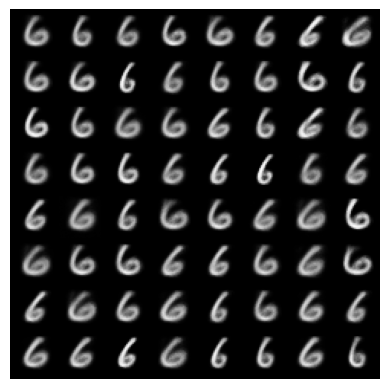

100%|██████████| 98/98 [00:00<00:00, 164.53it/s]


Epoch 1, Loss: 185.93227254588987


100%|██████████| 98/98 [00:00<00:00, 157.52it/s]


Epoch 2, Loss: 157.20969844248802


100%|██████████| 98/98 [00:00<00:00, 157.35it/s]


...

Epoch 4, Loss: 142.14842877094972


100%|██████████| 98/98 [00:00<00:00, 160.12it/s]


Epoch 5, Loss: 137.09737278967978


100%|██████████| 17/17 [00:00<00:00, 614.89it/s]

Test Loss: 134.2736006562348


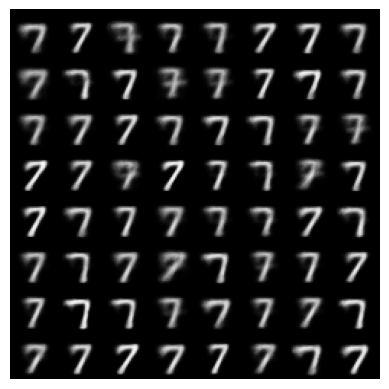

100%|██████████| 92/92 [00:00<00:00, 161.32it/s]


Epoch 1, Loss: 216.88750796137947


100%|██████████| 92/92 [00:00<00:00, 176.05it/s]


Epoch 2, Loss: 188.15831945794523


100%|██████████| 92/92 [00:00<00:00, 164.33it/s]


...

Epoch 4, Loss: 179.28945113882776


100%|██████████| 92/92 [00:00<00:00, 154.01it/s]


Epoch 5, Loss: 177.26052696320608


100%|██████████| 16/16 [00:00<00:00, 571.23it/s]

Test Loss: 175.89797879636166


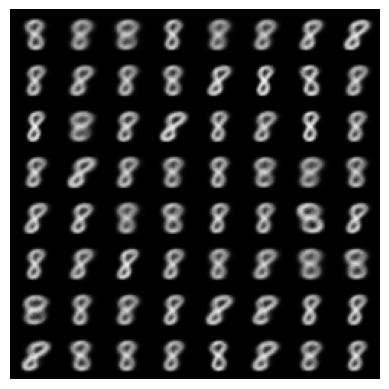

100%|██████████| 93/93 [00:00<00:00, 152.20it/s]


Epoch 1, Loss: 190.66616763321568


100%|██████████| 93/93 [00:00<00:00, 156.95it/s]


Epoch 2, Loss: 157.6430349704257


100%|██████████| 93/93 [00:00<00:00, 156.55it/s]


...

Epoch 4, Loss: 144.804704572197


100%|██████████| 93/93 [00:00<00:00, 161.56it/s]


Epoch 5, Loss: 140.6051276343713


100%|██████████| 16/16 [00:00<00:00, 548.15it/s]

Test Loss: 137.95693785229807


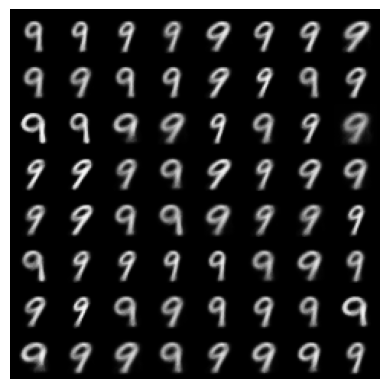

In [9]:
def train(train_data=None, test_data=None, t= None):
    # Hyperparameters
    input_dim = 28 * 28
    hidden_dim = 400
    output_dim = 20
    batch_size = 64
    num_epochs = 5
    learning_rate = 1e-3

    # Data loader
    train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
    test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=False)

    # Model, loss function and optimizer
    model = VAE(input_dim, hidden_dim, output_dim)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # Training loop
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        for batch_idx, (data, _) in enumerate(tqdm(train_loader)):
            data = data.view(-1, 28 * 28)
            optimizer.zero_grad()
            x_recon, mu, logvar = model(data)
            loss = model.loss_function(data, x_recon, mu, logvar)
            loss.backward()
            train_loss += loss.item()
            optimizer.step()

        print(f'Epoch {epoch + 1}, Loss: {train_loss / len(train_loader.dataset)}')

        # Save the model checkpoint
        torch.save(model.state_dict(), f'./vae_mnist_{t}.pth')
    return model
def test(model, test_data = None, batch_size= None, t= None):
    test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=False)
    # Load the model checkpoint
    model.load_state_dict(torch.load(f'./vae_mnist_{t}.pth'))
    for epoch in range(1):
        model.eval()
        test_loss = 0
        with torch.no_grad():
            for batch_idx, (data, _) in enumerate(tqdm(test_loader)):
                data = data.view(-1, 28 * 28)
                x_recon, mu, logvar = model(data)
                loss = model.loss_function(data, x_recon, mu, logvar)
                test_loss += loss.item()

        print(f'Test Loss: {test_loss / len(test_loader.dataset)}')

        # Generate samples
        samples = model.generate(64, output_dim=20)
        grid = make_grid(samples, nrow=8)
        plt.imshow(grid.permute(1, 2, 0).numpy())
        plt.axis('off')
        plt.show()
if __name__ == "__main__":
    input_dim = 28 * 28
    hidden_dim = 400
    output_dim = 2
    batch_size = 128
    num_epochs = 10
    learning_rate = 1e-3
    for i in range(10):
        model = train(train_data[i], test_data[i], t= i)
        test(model, test_data[i], batch_size= 64, t= i)


#### Populate Replay Buffer with your generated samples

For each of these use cases, we will adopt reservoir sampling. We first fix the size of the memory buffer to N samples, for instance 10000. The idea is that at each time step, we should save equal number of samples for each of the previously seen class instances.

If you recall, each of our contexts has only 2 class labels.
So, at the end of the first task, we will store 5000 samples from labels [0] and [1].
Similarily at the end of the second task, we will store 2500 samples from labels [0], [1], [2], [3]
Continue it till the final context


In [11]:
generator = VAE(28*28, 400, 20)
mem_size = 5000
replay = []
for i in range(4):
    replay.append([])
    for j in range(2*(i+1)):
        generator.load_state_dict(torch.load(f'./vae_mnist_{j}.pth'))
        # Generate samples
        samples = generator.generate(mem_size//(2*(i+1)), output_dim=20)
        for sample in samples:
            replay[i].append((sample, j))



In [12]:
model = Classifier(input_dim=28*28, hidden_dim=256, output_dim=10)
for i in range(5):
    if i == 0:
        train_classifier(model, train_data_cl[i], test_data_cl[i], num_epochs=5, batch_size=64, learning_rate=0.1)
    else:
        train_classifier(model, train_data_cl[i]+ replay[i-1], test_data_cl[i], num_epochs=10, batch_size=64, learning_rate=0.1)
    #torch.save(model.state_dict(), f'/app/src/model_replay/replay_{i}.pth')

100%|██████████| 198/198 [00:02<00:00, 87.29it/s]


Epoch [1/5], Loss: 0.1848


100%|██████████| 198/198 [00:02<00:00, 91.47it/s]


Epoch [2/5], Loss: 0.0066


100%|██████████| 198/198 [00:02<00:00, 90.42it/s]


...

Epoch [8/10], Loss: 0.0083


100%|██████████| 263/263 [00:02<00:00, 91.20it/s]


Epoch [9/10], Loss: 0.0083


100%|██████████| 263/263 [00:03<00:00, 85.77it/s]


Epoch [10/10], Loss: 0.0409
Accuracy of the model on the test data: 68.29%


#### Experience Replay

Now, we could perform the similar experiments with real data samples directly from the dataset. Use the same reservoir sampling approach to populate the replay buffer

In [13]:
mem_size = 10000
labels = [[[0],[1]], [[0],[1],[2],[3]], [[0],[1],[2],[3],[4],[5]], [[0],[1],[2],[3],[4],[5],[6],[7]], [[0],[1],[2],[3],[4],[5],[6], [7],[8],[9]]]
size_labels = [len(i) for i in labels]          ###[2, 4, 6, 8, 10]
count = [[mem_size//size_labels[i] for _ in range(size_labels[i])] for i in range(len(size_labels)-1)]  ###[5000, 2500, 1250, 625]
### count: [[5000, 5000], [2500, 2500, 2500, 2500], [1666, 1666, 1666, 1666, 1666, 1666], [1250, 1250, 1250, 1250, 1250, 1250, 1250, 1250]]
from tqdm import tqdm
#labels = [[0], [1], [2]]
replay = {'context_0': [], 'context_1': [], 'context_2': [], 'context_3': []}
for j in range(4):
    for k in range(2*(j+1)):
        c=0
        for i in tqdm(range(len(mnist_trainset))):
            if c == count[j][k]:
                break
            if mnist_trainset[i][1] in labels[j][k]:
                replay[f'context_{j}'].append((mnist_trainset[i][0], mnist_trainset[i][1]))
                c+= 1

 20%|█▉        | 11717/60000 [00:00<00:02, 21372.93it/s]


#### Train all the contexts using replay buffer

In [14]:
model = Classifier(input_dim=28*28, hidden_dim=256, output_dim=10)
for i in range(5):

    #model.load_state_dict(torch.load(f'/app/src/model_replay/replay_{i}.pth'))
    #model = train_classifier(model, train_data[i], test_data[i], num_epochs=5, batch_size=32, learning_rate=0.001)
    if i == 0:
        train_classifier(model, train_data_cl[i], test_data_cl[i], num_epochs=5, batch_size=64, learning_rate=0.1)
    else:
        train_classifier(model, train_data_cl[i]+ replay[f'context_{i-1}'], test_data_cl[i], num_epochs=10, batch_size=64, learning_rate=0.1)
    #torch.save(model.state_dict(), f'/app/src/model_replay/replay_{i}.pth')

100%|██████████| 198/198 [00:01<00:00, 109.48it/s]


Epoch [1/5], Loss: 0.1606


100%|██████████| 198/198 [00:01<00:00, 108.09it/s]


Epoch [2/5], Loss: 0.0062


100%|██████████| 198/198 [00:01<00:00, 102.35it/s]


...

Epoch [8/10], Loss: 0.0091


100%|██████████| 341/341 [00:04<00:00, 81.74it/s]


Epoch [9/10], Loss: 0.0074


100%|██████████| 341/341 [00:04<00:00, 83.41it/s]


Epoch [10/10], Loss: 0.0044
Accuracy of the model on the test data: 98.67%
